LOAD DATASET

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dewminimnaadi/sri-lanka-flood-risk-and-inundation-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.48M/1.48M [00:00<00:00, 46.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dewminimnaadi/sri-lanka-flood-risk-and-inundation-dataset/versions/1


In [ ]:
ls /root/.cache/kagglehub/datasets/dewminimnaadi/sri-lanka-flood-risk-and-inundation-dataset/versions/1

sri_lanka_flood_risk_dataset_25000.csv


IMPORT LIBRARIES


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/root/.cache/kagglehub/datasets/dewminimnaadi/sri-lanka-flood-risk-and-inundation-dataset/versions/1/sri_lanka_flood_risk_dataset_25000.csv")
df.head()

,record_id,district,place_name,latitude,longitude,elevation_m,distance_to_river_m,landcover,soil_type,water_supply,...,infrastructure_score,nearest_hospital_km,nearest_evac_km,flood_risk_score,flood_occurrence_current_event,inundation_area_sqm,is_good_to_live,reason_not_good_to_live,is_synthetic,generation_date
0,F100000,Kegalle,Kudagama,7.416887,81.789107,88,339.2,Wetland,Loamy,Municipal,...,12,2.76,2.74,39.56,No,0,No,Poor infrastructure,True,2025-06-02
1,F100001,Matara,Kiriwatta,6.266956,81.041369,58,1257.6,Agriculture,Clay,Municipal,...,46,1.61,8.45,30.64,No,0,Yes,NaN,True,2024-11-14
2,F100002,Trincomalee,Uduthota East,6.742164,80.927326,80,5225.3,Forest,Silty,Well,...,30,4.40,3.01,35.60,No,0,Yes,NaN,True,2024-03-01
3,F100003,Puttalam,Mahagama East,5.922365,81.484788,111,2950.4,Urban,Sandy,Surface water,...,58,11.44,4.94,17.44,No,0,Yes,NaN,True,2024-11-06
4,F100004,Matara,Welimulla East,7.899872,80.826149,26,228.3,Agriculture,Silty,Well,...,45,17.85,4.65,61.92,No,0,No,High flood risk,True,2024-07-21


DATA CLEANING

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   record_id                       25000 non-null  object 
 1   district                        25000 non-null  object 
 2   place_name                      25000 non-null  object 
 3   latitude                        25000 non-null  float64
 4   longitude                       25000 non-null  float64
 5   elevation_m                     25000 non-null  int64  
 6   distance_to_river_m             25000 non-null  float64
 7   landcover                       25000 non-null  object 
 8   soil_type                       25000 non-null  object 
 9   water_supply                    25000 non-null  object 
 10  electricity                     24211 non-null  object 
 11  road_quality                    25000 non-null  object 
 12  population_density_per_km2      

In [ ]:
df = df.drop(['record_id', 'place_name', 'reason_not_good_to_live','generation_date',], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   district                        25000 non-null  object 
 1   latitude                        25000 non-null  float64
 2   longitude                       25000 non-null  float64
 3   elevation_m                     25000 non-null  int64  
 4   distance_to_river_m             25000 non-null  float64
 5   landcover                       25000 non-null  object 
 6   soil_type                       25000 non-null  object 
 7   water_supply                    25000 non-null  object 
 8   electricity                     25000 non-null  object 
 9   road_quality                    25000 non-null  object 
 10  population_density_per_km2      25000 non-null  int64  
 11  built_up_percent                25000 non-null  float64
 12  urban_rural                     

In [ ]:
df['electricity'] = df['electricity'].fillna('Unknown')

In [ ]:
cat_cols = [
    'landcover',
    'soil_type',
    'water_supply',
    'electricity',
    'road_quality',
    'urban_rural',
    'water_presence_flag',
    'flood_occurrence_current_event',
    'is_good_to_live'
]

In [ ]:
# label encoding
from sklearn.preprocessing import LabelEncoder
import joblib

encoders = {}
mappings = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

    encoders[col] = le

    # mapping
    mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

    # Save
    joblib.dump({
    'encoders': encoders,
    'mappings': mappings
}, 'encoders_flood.joblib')


In [ ]:
df.head()

,district,latitude,longitude,elevation_m,distance_to_river_m,landcover,soil_type,water_supply,electricity,road_quality,...,water_presence_flag,historical_flood_count,infrastructure_score,nearest_hospital_km,nearest_evac_km,flood_risk_score,flood_occurrence_current_event,inundation_area_sqm,is_good_to_live,is_synthetic
0,Kegalle,7.416887,81.789107,88,339.2,6,1,0,1,3,...,0,0,12,2.76,2.74,39.56,0,0,0,True
1,Matara,6.266956,81.041369,58,1257.6,0,0,0,1,0,...,1,0,46,1.61,8.45,30.64,0,0,1,True
2,Trincomalee,6.742164,80.927326,80,5225.3,2,4,4,1,3,...,1,0,30,4.40,3.01,35.60,0,0,1,True
3,Puttalam,5.922365,81.484788,111,2950.4,5,3,2,0,1,...,1,0,58,11.44,4.94,17.44,0,0,1,True
4,Matara,7.899872,80.826149,26,228.3,0,4,4,1,1,...,0,1,45,17.85,4.65,61.92,0,0,0,True


In [ ]:
for col, mapping in mappings.items():
    print(f"\n{col}:")
    for key, value in mapping.items():
        print(f"{key} → {value}")


landcover:
Agriculture → 0
Bare Soil → 1
Forest → 2
Plantation → 3
Scrub → 4
Urban → 5
Wetland → 6

soil_type:
Clay → 0
Loamy → 1
Peaty → 2
Sandy → 3
Silty → 4

water_supply:
Municipal → 0
Rainwater harvesting → 1
Surface water → 2
Tube-well → 3
Well → 4

electricity:
Grid → 0
Mixed → 1
Off-grid (solar) → 2
Unknown → 3

road_quality:
Fair → 0
Good (paved) → 1
No road access → 2
Poor (unpaved) → 3

urban_rural:
Rural → 0
Urban → 1

water_presence_flag:
Likely → 0
Unlikely → 1

flood_occurrence_current_event:
No → 0
Yes → 1

is_good_to_live:
No → 0
Yes → 1


In [ ]:
df = df.drop(columns=['district', 'is_synthetic'])

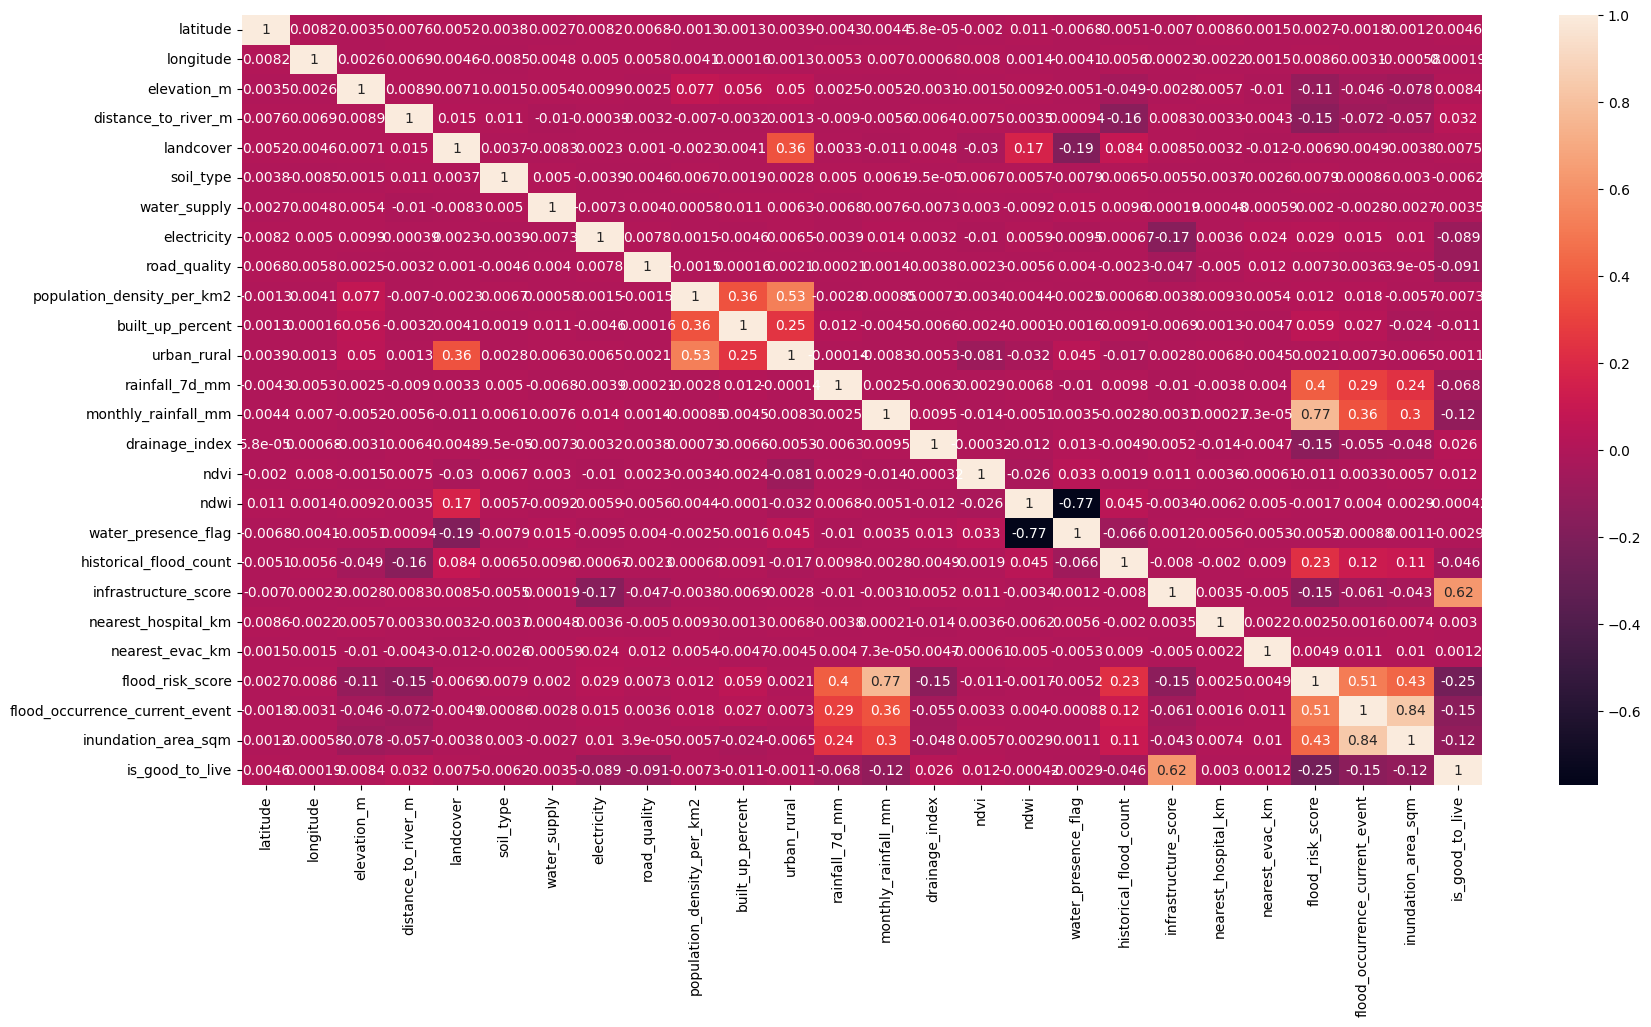

In [ ]:
# Check correlation using heatmap

plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

DATA VISUALIZATION

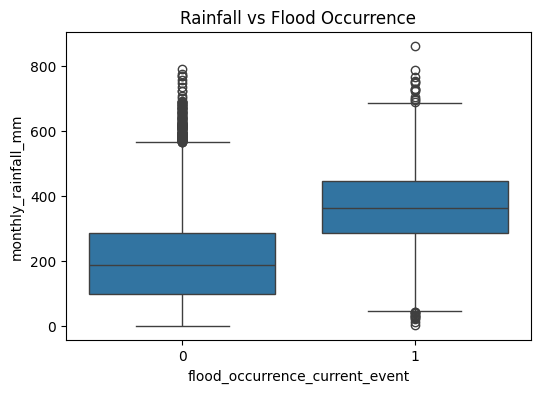

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(
    x='flood_occurrence_current_event',
    y='monthly_rainfall_mm',
    data=df
)

plt.title('Rainfall vs Flood Occurrence')
plt.show()

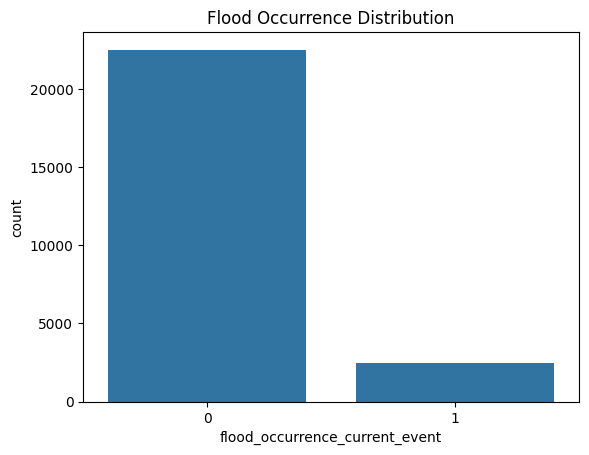

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='flood_occurrence_current_event', data=df)
plt.title('Flood Occurrence Distribution')
plt.show()

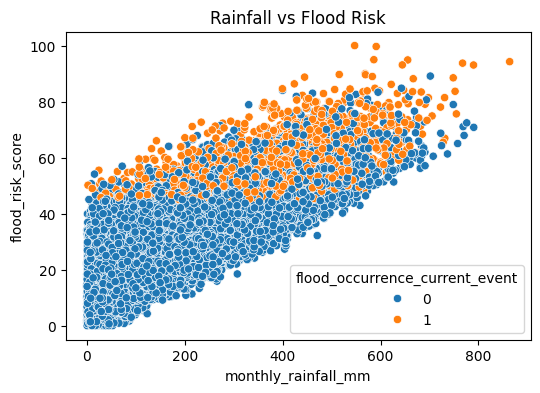

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.scatterplot(
    x='monthly_rainfall_mm',
    y='flood_risk_score',
    hue='flood_occurrence_current_event',
    data=df
)

plt.title('Rainfall vs Flood Risk')
plt.show()

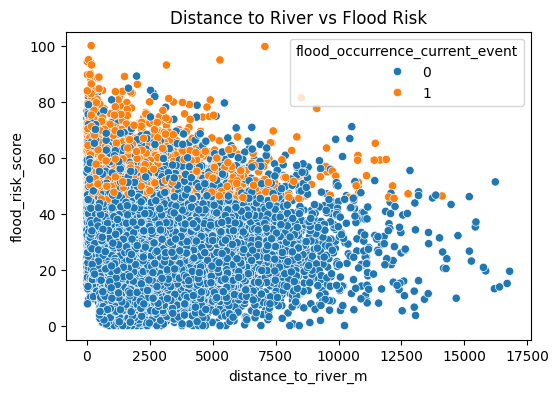

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='distance_to_river_m',
    y='flood_risk_score',
    hue='flood_occurrence_current_event',
    data=df
)

plt.title('Distance to River vs Flood Risk')
plt.show()

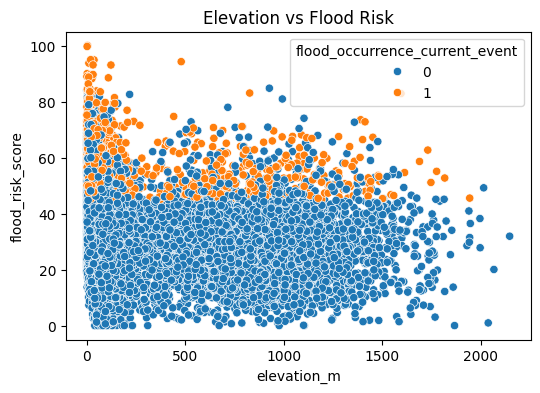

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='elevation_m',
    y='flood_risk_score',
    hue='flood_occurrence_current_event',
    data=df
)

plt.title('Elevation vs Flood Risk')
plt.show()

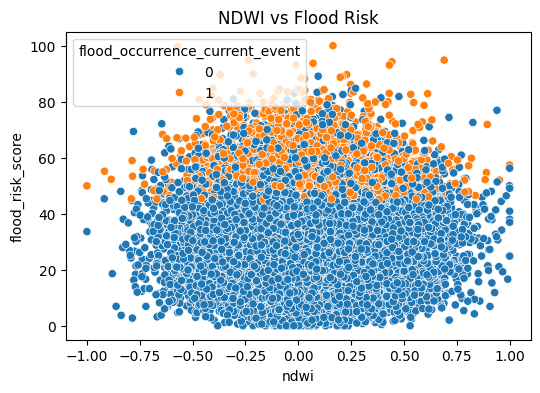

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='ndwi',
    y='flood_risk_score',
    hue='flood_occurrence_current_event',
    data=df
)

plt.title('NDWI vs Flood Risk')
plt.show()

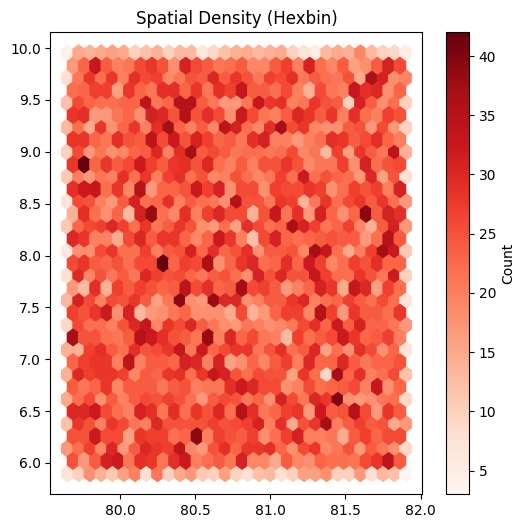

In [ ]:
plt.figure(figsize=(6,6))

plt.hexbin(
    df['longitude'],
    df['latitude'],
    gridsize=30,
    cmap='Reds'
)

plt.colorbar(label='Count')
plt.title('Spatial Density (Hexbin)')
plt.show()

In [ ]:
df = df.drop(columns=[
    'nearest_hospital_km',
    'nearest_evac_km',
    'water_presence_flag',
    'water_supply',
    'electricity',
    'road_quality'
])

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   latitude                        25000 non-null  float64
 1   longitude                       25000 non-null  float64
 2   elevation_m                     25000 non-null  int64  
 3   distance_to_river_m             25000 non-null  float64
 4   landcover                       25000 non-null  int64  
 5   soil_type                       25000 non-null  int64  
 6   population_density_per_km2      25000 non-null  int64  
 7   built_up_percent                25000 non-null  float64
 8   urban_rural                     25000 non-null  int64  
 9   rainfall_7d_mm                  25000 non-null  float64
 10  monthly_rainfall_mm             25000 non-null  float64
 11  drainage_index                  25000 non-null  float64
 12  ndvi                            

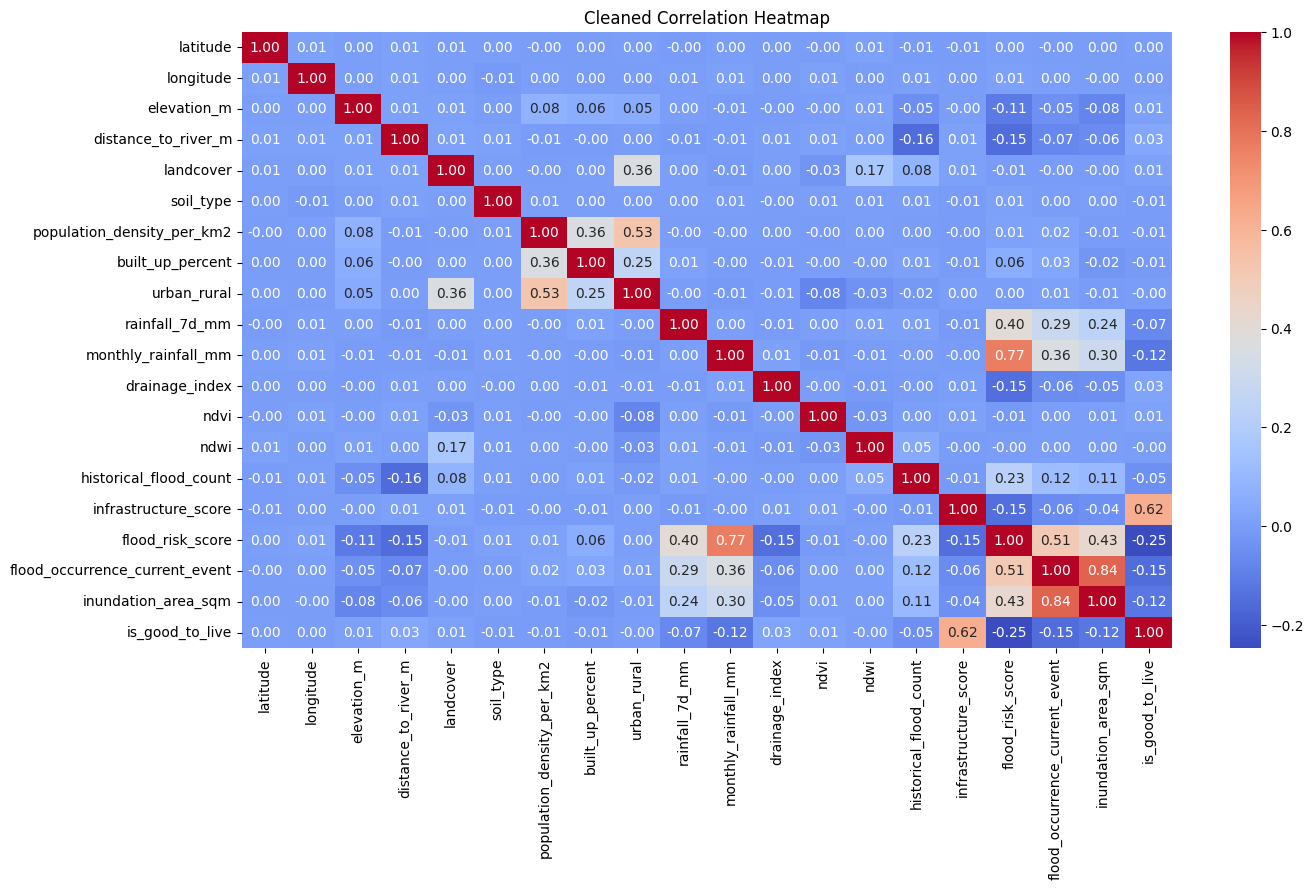

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap='coolwarm'
)

plt.title('Cleaned Correlation Heatmap')
plt.show()

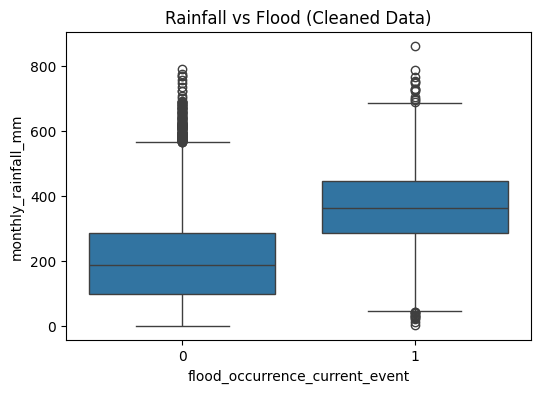

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='flood_occurrence_current_event',
    y='monthly_rainfall_mm',
    data=df
)

plt.title('Rainfall vs Flood (Cleaned Data)')
plt.show()

In [ ]:
# Feature scaling (optional for tree-based models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler to file
joblib.dump(scaler, 'scaler_flood.pkl')
print("Scaler saved successfully!")

Scaler saved successfully!


TRAINING

In [ ]:
X = df.drop(columns=['flood_risk_score', 'flood_occurrence_current_event', 'is_good_to_live'])
y = df['flood_risk_score']

MODELLING

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
# RANDOM FOREST
model_R = RandomForestRegressor(n_estimators=100, random_state=42)
model_R.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model_R.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 4.371237606848001
Root Mean Squared Error: 2.090750488902968
R^2 Score: 0.979463168319514


In [ ]:
# DECISION TREE
from sklearn.tree import DecisionTreeRegressor
model_d= DecisionTreeRegressor(max_depth=5, random_state=42)
model_d.fit(X_train, y_train)  # No scaling needed

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
# Predict on test data
y_pred = model_d.predict(X_test)
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score (accuracy): {r2}")

Mean Squared Error (MSE): 42.107859627829676
Root Mean Squared Error (RMSE): 6.489056913591503
R² Score (accuracy): 0.8021699794475754


SAVE MODEL

In [ ]:
# Save the trained model
joblib.dump(model_R, "best_model_FLOOD.pkl")

['best_model_FLOOD.pkl']

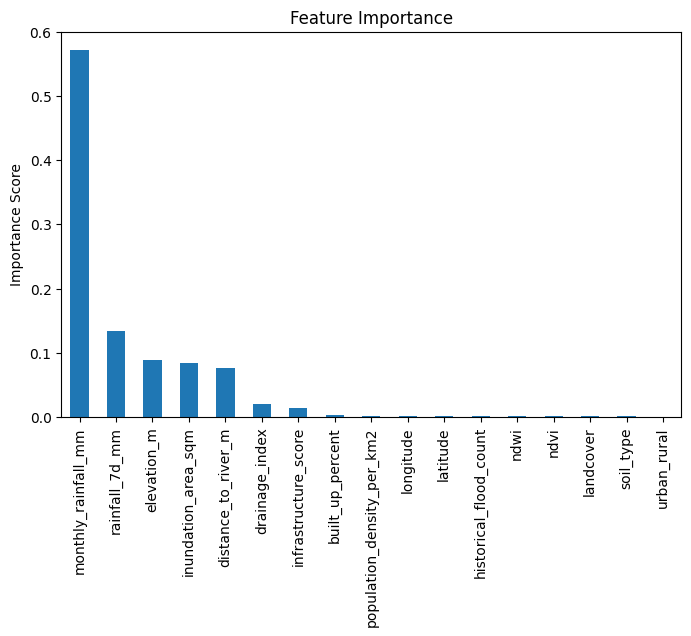

In [ ]:
# after training
import pandas as pd
import matplotlib.pyplot as plt

importance = model_R.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.plot(kind='bar')

plt.title('Feature Importance')
plt.ylabel('Importance Score')
plt.show()

# **Another modelling**

In [53]:
Xc = df.drop(columns=['flood_risk_score', 'flood_occurrence_current_event', 'is_good_to_live'])
yc = df['is_good_to_live']

In [54]:
from sklearn.model_selection import train_test_split

Xc_train,Xc_test,yc_train,yc_test = train_test_split(Xc,yc,test_size=0.2,random_state=24)

In [55]:
from sklearn.linear_model import LogisticRegression

modelLR = LogisticRegression(max_iter=2000)
modelLR.fit(Xc_train,yc_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

In [56]:
yc_pred =modelLR.predict(Xc_test)

In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(yc_test, yc_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(yc_test, yc_pred)
print("Confusion Matrix:\n", cm)

print(classification_report(yc_test, yc_pred))

Accuracy: 0.904
Confusion Matrix:
 [[1052  309]
 [ 171 3468]]
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      1361
           1       0.92      0.95      0.94      3639

    accuracy                           0.90      5000
   macro avg       0.89      0.86      0.87      5000
weighted avg       0.90      0.90      0.90      5000



In [58]:
from sklearn.naive_bayes import GaussianNB

modelGNB = GaussianNB()
modelGNB.fit(Xc_train, yc_train)

yc_pred = modelGNB.predict(Xc_test)
print("Accuracy:", accuracy_score(yc_test, yc_pred))


Accuracy: 0.8812


In [59]:
from sklearn.neighbors import KNeighborsClassifier

modelKC = KNeighborsClassifier(n_neighbors=5)
modelKC.fit(Xc_train, yc_train)

yc_pred = modelKC.predict(Xc_test)
print("Accuracy:", accuracy_score(yc_test, yc_pred))

Accuracy: 0.7124


In [60]:
from sklearn.tree import DecisionTreeClassifier

modelDTC = DecisionTreeClassifier(random_state=42)
modelDTC.fit(Xc_train, yc_train)

yc_pred = modelDTC.predict(Xc_test)
print("Accuracy:", accuracy_score(yc_test, yc_pred))

Accuracy: 0.9116


In [61]:
from sklearn.ensemble import RandomForestClassifier

modelRFC = RandomForestClassifier(n_estimators=100, random_state=42)
modelRFC.fit(Xc_train, yc_train)

yc_pred = modelRFC.predict(Xc_test)
print("Accuracy:", accuracy_score(yc_test, yc_pred))

Accuracy: 0.9536


In [62]:
from sklearn.ensemble import GradientBoostingClassifier

modelG = GradientBoostingClassifier()
modelG.fit(Xc_train, yc_train)

yc_pred = modelG.predict(Xc_test)
print("Accuracy:", accuracy_score(yc_test, yc_pred))

Accuracy: 0.9572


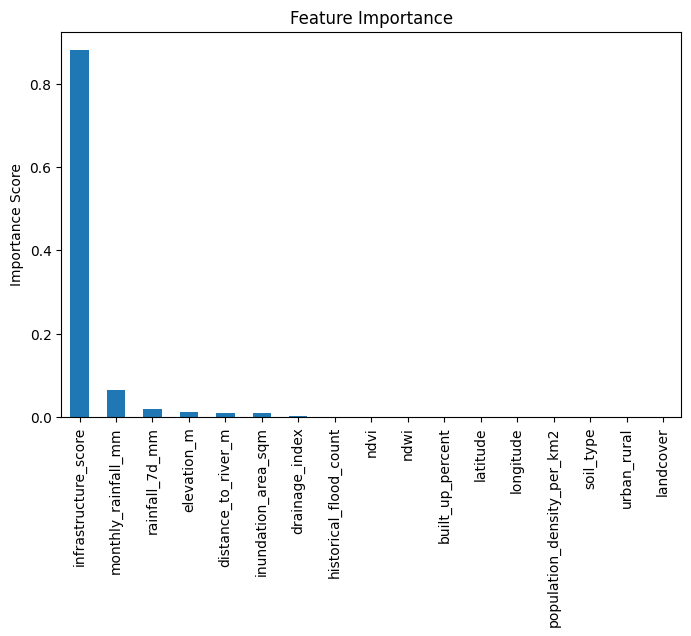

In [63]:
# after training
import pandas as pd
import matplotlib.pyplot as plt

importance = modelG.feature_importances_
features = Xc.columns

feat_imp = pd.Series(importance, index=features)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.plot(kind='bar')

plt.title('Feature Importance')
plt.ylabel('Importance Score')
plt.show()

In [64]:
# Save the trained model
joblib.dump(modelG, "best_model_good_to_live.pkl")

['best_model_good_to_live.pkl']